## 0. Config

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)

## 1. Data Loading

In [3]:
df = pd.read_csv("cinemas.csv", index_col=0)
df.head(10)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,4834,Wes Studi,0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,NaN,4,0
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,48350,Jack Davenport,0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,NaN,8,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,11700,Stephanie Sigman,1,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,NaN,1,0
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,106759,Joseph Gordon-Levitt,0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,NaN,3,0
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens,8,143,NaN,0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0,NaN,9,0
5,Color,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,Daryl Sabara,John Carter,212204,1873,Polly Walker,1,alien|american civil war|male nipple|mars|prin...,http://www.imdb.com/title/tt0401729/?ref_=fn_t...,738,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000,NaN,3,0
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,J.K. Simmons,Spider-Man 3,383056,46055,Kirsten Dunst,0,sandman|spider man|symbiote|venom|villain,http://www.imdb.com/title/tt0413300/?ref_=fn_t...,1902,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0,NaN,2,0
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Brad Garrett,Tangled,294810,2036,M.C. Gainey,1,17th century|based on fairy tale|disney|flower...,http://www.imdb.com/title/tt0398286/?ref_=fn_t...,387,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000,NaN,1,0
8,Color,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,Chris Hemsworth,Avengers: Age of Ultron,462669,92000,Scarlett Johansson,4,artificial intelligence|based on comic book|ca...,http://www.imdb.com/title/tt2395427/?ref_=fn_t...,1117,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000,NaN,4,0
9,Color,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,Alan Rickman,Harry Potter and the Half-Blood Prince,321795,58753,Rupert Grint,3,blood|book|love|potion|professor,http://www.imdb.com/title/tt0417741/?ref_=fn_t...,973,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000,NaN,7,0


## My idea for the task:
The main goal is to create a regression model to predict the gross feature. To improve model performance I'll create a classification model to predict missing values in the content_ratio column.

## 2. EDA

### 2.0 Data overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5031 non-null   str    
 1   director_name              4946 non-null   str    
 2   num_critic_for_reviews     5000 non-null   float64
 3   duration                   5035 non-null   float64
 4   director_facebook_likes    4946 non-null   float64
 5   actor_3_facebook_likes     5027 non-null   float64
 6   actor_2_name               5037 non-null   str    
 7   actor_1_facebook_likes     5043 non-null   float64
 8   gross                      4161 non-null   float64
 9   genres                     5050 non-null   str    
 10  actor_1_name               5043 non-null   str    
 11  movie_title                5050 non-null   str    
 12  num_voted_users            5050 non-null   str    
 13  cast_total_facebook_likes  5050 non-null   int64  
 14  act

In [5]:
# df[pd.to_numeric(df.num_user_for_reviews,errors="coerce").isna()] # check
# df[pd.to_numeric(df.num_critic_for_reviews,errors="coerce").isna()] # check 
# df[pd.to_numeric(df.num_voted_users, errors="coerce").isna()] # check 
# df[pd.to_numeric(df.facenumber_in_poster, errors="coerce").isna()] # check 
df["num_user_for_reviews"] = pd.to_numeric(df.num_user_for_reviews, errors="coerce")
df["num_critic_for_reviews"] = pd.to_numeric(df.num_critic_for_reviews, errors="coerce")
df["num_voted_users"] = pd.to_numeric(df.num_voted_users, errors="coerce")
df["facenumber_in_poster"] = pd.to_numeric(df.facenumber_in_poster, errors="coerce")

In [6]:
df.num_user_for_reviews

0       3054.0
1       1238.0
2        994.0
3       2701.0
4          NaN
         ...  
5045       6.0
5046     359.0
5047       3.0
5048       9.0
5049      84.0
Name: num_user_for_reviews, Length: 5050, dtype: float64

In [7]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Unnamed: 28,war_symb_title,point_symb_title
count,5000.000000,5035.000000,4946.000000,5027.000000,5043.000000,4.161000e+03,5.049000e+03,5050.000000,5037.000000,5028.000000,4.557000e+03,4942.000000,5037.000000,5050.000000,4721.000000,5050.000000,2.000000,5050.000000,5050.000000
mean,140.167200,107.174578,686.391630,664.526358,6551.834226,4.951350e+07,8.357902e+04,9688.141188,1.373238,272.495028,3.971317e+07,2042.540065,1650.540798,6.461802,2.217354,7517.337822,212.001500,2.214851,0.007327
std,121.815619,25.192929,2811.353082,2179.937100,15011.950367,9.658335e+07,1.384277e+05,18153.603823,2.013966,377.841705,2.059827e+08,2816.518736,4039.812533,1.710715,1.370455,19308.667793,299.811154,1.715557,0.113226
min,1.000000,7.000000,0.000000,0.000000,-32.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.000000,0.000000,0.003000,0.000000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.333658e+06,8.546000e+03,1411.250000,0.000000,64.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000,106.002250,1.000000,0.000000
50%,110.000000,103.000000,49.000000,372.000000,986.000000,2.551750e+07,3.433800e+04,3086.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000,212.001500,2.000000,0.000000
75%,195.000000,118.000000,197.000000,636.000000,11000.000000,6.231888e+07,9.612900e+04,13740.500000,2.000000,325.250000,4.450000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000,318.000750,3.000000,0.000000
max,813.000000,511.000000,23000.000000,100500.000000,640000.000000,4.444444e+09,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,200000.000000,137000.000000,98.000000,16.000000,349000.000000,424.000000,16.000000,5.000000


In [8]:
# things to check:
#   - acotr_1_facebook_likes = -32
#   - title_year = 200000 
#   - imdb_score = 98

In [9]:
df.nunique().sort_values(ascending=True)

Unnamed: 28                     2
color                           3
point_symb_title                5
war_symb_title                 15
facenumber_in_poster           19
content_rating                 19
aspect_ratio                   24
language                       48
country                        66
imdb_score                     80
title_year                     93
duration                      191
director_facebook_likes       435
budget                        441
num_critic_for_reviews        529
movie_facebook_likes          876
actor_1_facebook_likes        880
actor_3_facebook_likes        907
genres                        916
actor_2_facebook_likes        918
num_user_for_reviews          954
actor_1_name                 2099
director_name                2400
actor_2_name                 3034
actor_3_name                 3523
cast_total_facebook_likes    3980
gross                        4037
plot_keywords                4761
num_voted_users              4828
movie_title   

In [10]:
numeric_feauteres = df.select_dtypes(include=[np.number]).columns.to_list()
non_numeric_feauteres = df.select_dtypes(include=['str']).columns.to_list()
print(f"numeric features({len(numeric_feauteres)}): {numeric_feauteres}\nnon-numeric features({len(non_numeric_feauteres)}): ", non_numeric_feauteres)

numeric features(19): ['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'Unnamed: 28', 'war_symb_title', 'point_symb_title']
non-numeric features(12):  ['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


### 2.1 missing values and duplicates

In [11]:
(df.notnull().sum() / len(df)).sort_values(ascending=True)

Unnamed: 28                  0.000396
gross                        0.823960
budget                       0.902376
aspect_ratio                 0.934851
content_rating               0.939010
plot_keywords                0.969505
title_year                   0.978614
director_facebook_likes      0.979406
director_name                0.979406
num_critic_for_reviews       0.990099
actor_3_name                 0.995446
actor_3_facebook_likes       0.995446
num_user_for_reviews         0.995644
color                        0.996238
duration                     0.997030
language                     0.997228
actor_2_facebook_likes       0.997426
facenumber_in_poster         0.997426
actor_2_name                 0.997426
actor_1_name                 0.998614
actor_1_facebook_likes       0.998614
country                      0.999010
num_voted_users              0.999802
war_symb_title               1.000000
cast_total_facebook_likes    1.000000
movie_title                  1.000000
genres      

In [12]:
df["Unnamed: 28"].value_counts() 
print(df[df["Unnamed: 28"].notnull()])
# only to rows are not missing and we don't relly know what is this information about so we drop this column
df = df.drop("Unnamed: 28", axis=1)

      color       director_name  num_critic_for_reviews  duration  director_facebook_likes  actor_3_facebook_likes actor_2_name  actor_1_facebook_likes      gross                  genres   actor_1_name  movie_title  num_voted_users  cast_total_facebook_likes actor_3_name  facenumber_in_poster                                      plot_keywords                                    movie_imdb_link  num_user_for_reviews language  country content_rating      budget  title_year  actor_2_facebook_likes  imdb_score  aspect_ratio  movie_facebook_likes  Unnamed: 28  war_symb_title  point_symb_title
1761  Color           IC Wiener                   666.0      69.0                     17.0                100500.0      Nibbler                   -32.0  1111111.0   Fantasy|Comedy|Sci-Fi  Philip J. Fry  No name yet             41.0                        404  Turangalila                   7.0  future|mission|space|delivery|bite my shiny me...  http://www.imdb.com/title/tt0119210/?ref_=fn_t...           

In [13]:
df[df.duplicated(keep="first")].sort_values(by="num_critic_for_reviews")
df = df.drop_duplicates()
len(df)

5000

In [14]:
df[df.duplicated(keep=False, subset=(["movie_title","num_voted_users"]))].sort_values(by='movie_title')
# rows have small difference in features connected with number of likes or votes so we drop rows with lower value of num_voted_users. In two cases thsi value is equal so we drop rows with lower value of cast_tota_facebook_likes
df_sorted = df.sort_values(by=["movie_title", "num_voted_users", "cast_total_facebook_likes"], ascending=[True, False, False])
df = df_sorted.drop_duplicates(subset=["movie_title"], keep='first')
df.head(8)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
4448,Color,Tara Subkoff,35.0,101.0,37.0,56.0,Balthazar Getty,501.0,NaN,Drama|Horror|Mystery|Thriller,Timothy Hutton,#Horror,1547.0,1044,Lydia Hearst,1.0,bullying|cyberbullying|girl|internet|throat sl...,http://www.imdb.com/title/tt3526286/?ref_=fn_t...,42.0,English,USA,Not Rated,1500000.0,2015.0,418.0,3.3,NaN,750,3,0
3699,Color,Dan Trachtenberg,411.0,104.0,16.0,82.0,John Gallagher Jr.,14000.0,71897215.0,Drama|Horror|Mystery|Sci-Fi|Thriller,Bradley Cooper,10 Cloverfield Lane,126893.0,14504,Sumalee Montano,0.0,alien|bunker|car crash|kidnapping|minimal cast,http://www.imdb.com/title/tt1179933/?ref_=fn_t...,440.0,English,USA,PG-13,15000000.0,2016.0,338.0,7.3,2.35,33000,2,0
3016,Color,Timothy Hines,1.0,111.0,0.0,247.0,Kelly LeBrock,1000.0,14616.0,Drama,Christopher Lambert,10 Days in a Madhouse,314.0,2059,Alexandra Callas,1.0,NaN,http://www.imdb.com/title/tt3453052/?ref_=fn_t...,10.0,English,USA,R,12000000.0,2015.0,445.0,7.5,1.85,26000,3,0
2846,Color,Gil Junger,133.0,97.0,19.0,835.0,Heath Ledger,23000.0,38176108.0,Comedy|Drama|Romance,Joseph Gordon-Levitt,10 Things I Hate About You,222099.0,37907,Andrew Keegan,6.0,dating|protective father|school|shrew|teen movie,http://www.imdb.com/title/tt0147800/?ref_=fn_t...,549.0,English,USA,PG-13,16000000.0,1999.0,13000.0,7.2,1.85,10000,2,0
279,NaN,Christopher Barnard,NaN,22.0,0.0,NaN,NaN,5.0,NaN,Comedy,Mathew Buck,"10,000 B.C.",6.0,5,NaN,0.0,NaN,http://www.imdb.com/title/tt1869849/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.2,NaN,0,0,0
406,Color,Kevin Lima,84.0,100.0,36.0,439.0,Eric Idle,2000.0,66941559.0,Adventure|Comedy|Family,Ioan Gruffudd,102 Dalmatians,26413.0,4182,Jim Carter,1.0,dog|parole|parole officer|prison|puppy,http://www.imdb.com/title/tt0211181/?ref_=fn_t...,77.0,English,USA,G,85000000.0,2000.0,795.0,4.8,1.85,372,3,0
3421,Color,Robert Moresco,26.0,107.0,53.0,463.0,Brad Renfro,954.0,53481.0,Crime|Drama|Thriller,Brian Dennehy,10th & Wolf,5557.0,2512,Dash Mihok,5.0,desert storm|fbi|fbi agent|fragmentation grena...,http://www.imdb.com/title/tt0360323/?ref_=fn_t...,34.0,English,USA,R,8000000.0,2006.0,551.0,6.4,2.35,294,1,0
3645,Color,Greg Marcks,68.0,85.0,9.0,407.0,Barbara Hershey,861.0,NaN,Comedy|Crime|Drama,Henry Thomas,11:14,38273.0,2200,Shawn Hatosy,1.0,convenience store|multiple perspectives|murder...,http://www.imdb.com/title/tt0331811/?ref_=fn_t...,133.0,English,USA,R,6000000.0,2003.0,618.0,7.2,1.85,0,0,0


### 2.2 Feautures distribution

### 2.2.1 Numerical features

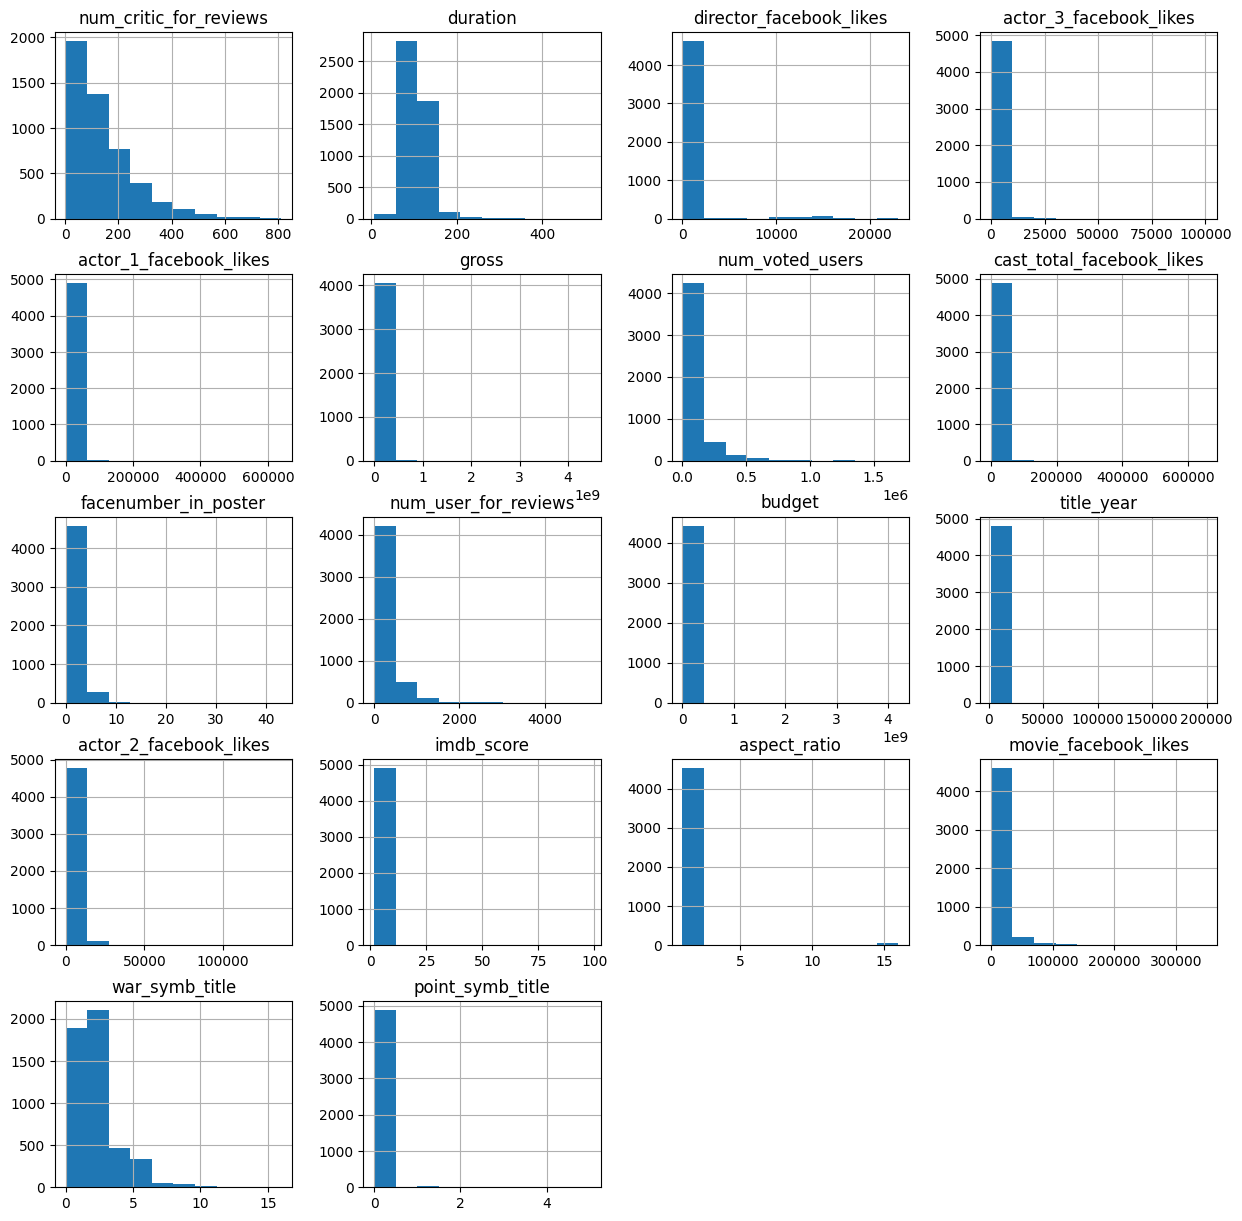

In [15]:
df.hist(figsize=(15,15))
plt.show()

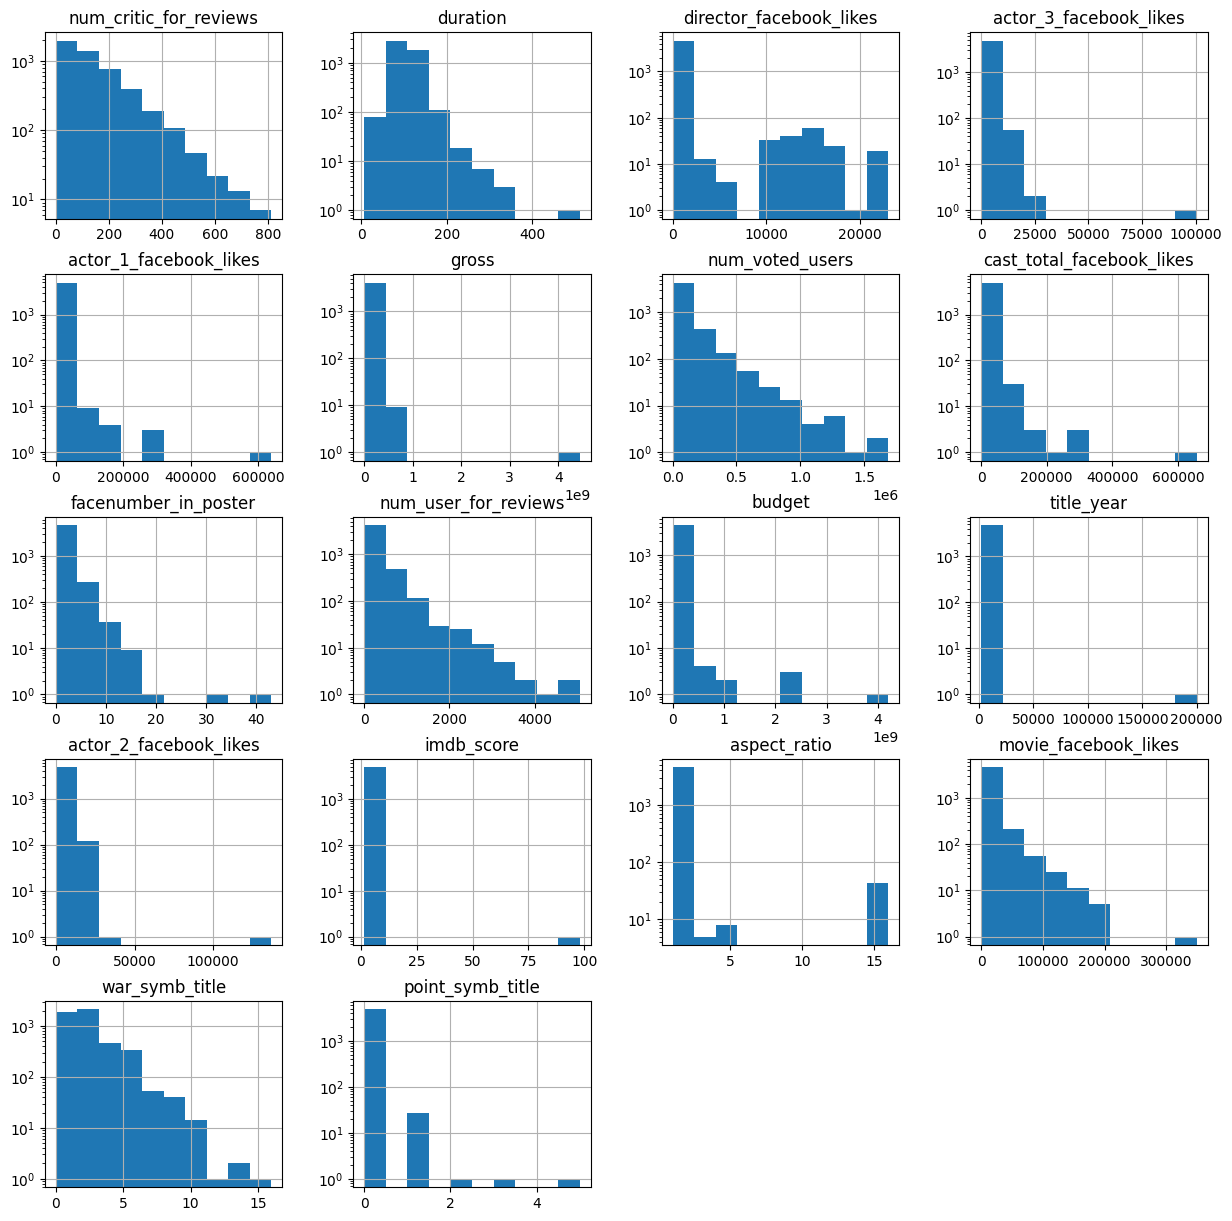

In [16]:
df.hist(figsize=(15,15), log=True)
plt.show()

In [17]:
# key observations:
#   - most of the feauters have right-skewed distribution -> log transformation might be use

In [18]:
df[df.title_year > 2020]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
5038,Color,Thomas L. Phillips,13.0,82.0,120.0,84.0,Joe Coffey,785.0,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary,NaN,133,1111,NaN,NaN,nudity|party|pirate|swimsuit|three word title,NaN,8,English,USA,NaN,200000.0,2012.0,98.0,5.4,16,3,0


In [19]:
df[df.imdb_score> 10]

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,actor_1_name,movie_title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,war_symb_title,point_symb_title
5038,Color,Thomas L. Phillips,13.0,82.0,120.0,84.0,Joe Coffey,785.0,NaN,Comedy|Horror|Thriller,Julianna Pitt,Sanctuary,NaN,133,1111,NaN,NaN,nudity|party|pirate|swimsuit|three word title,NaN,8,English,USA,NaN,200000.0,2012.0,98.0,5.4,16,3,0


In [20]:
# In row above we have some incorret information about imdb_score and title_year, furthermore there is no information about gorss so we drop this row
df = df[~((df.title_year == 200000) & (df.imdb_score == 98))]

In [21]:
df[df.actor_1_facebook_likes < 0] # we cap this value at 0
df.loc[df.actor_1_facebook_likes < 0, "actor_1_facebook_likes"] = 1

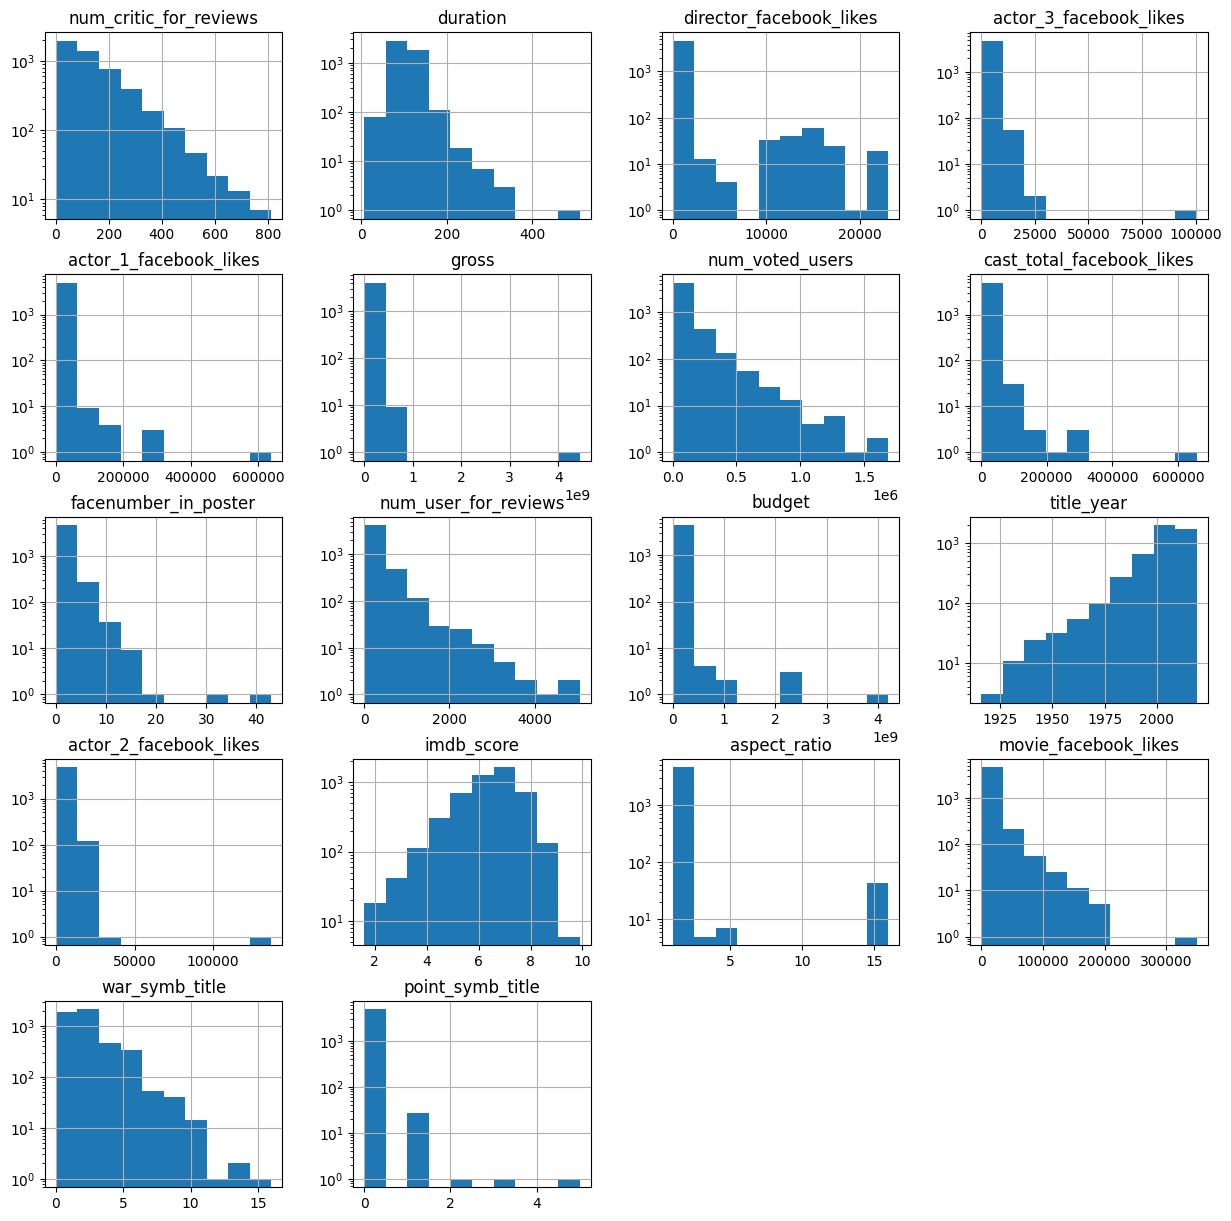

In [22]:
df.hist(figsize=(15,15), log=True)
plt.show()

### 2.2.2 Non-numerical features

In [23]:
df[non_numeric_feauteres].nunique().sort_values(ascending=False)

movie_title        4917
movie_imdb_link    4916
plot_keywords      4758
actor_3_name       3519
actor_2_name       3030
director_name      2398
actor_1_name       2096
genres              915
country              65
language             47
content_rating       18
color                 3
dtype: int64

In [24]:
# for each movie (there was also one duplicated imdb_link connected with different movies) we have different imdb_link and of course title so this features will be useless in terms of prediction
df.drop(["movie_imdb_link", "movie_title"], axis=1, inplace=True)

### 2.3 Correlation

In [25]:
cor = df.select_dtypes(include=[np.number]).corr()

<Axes: >

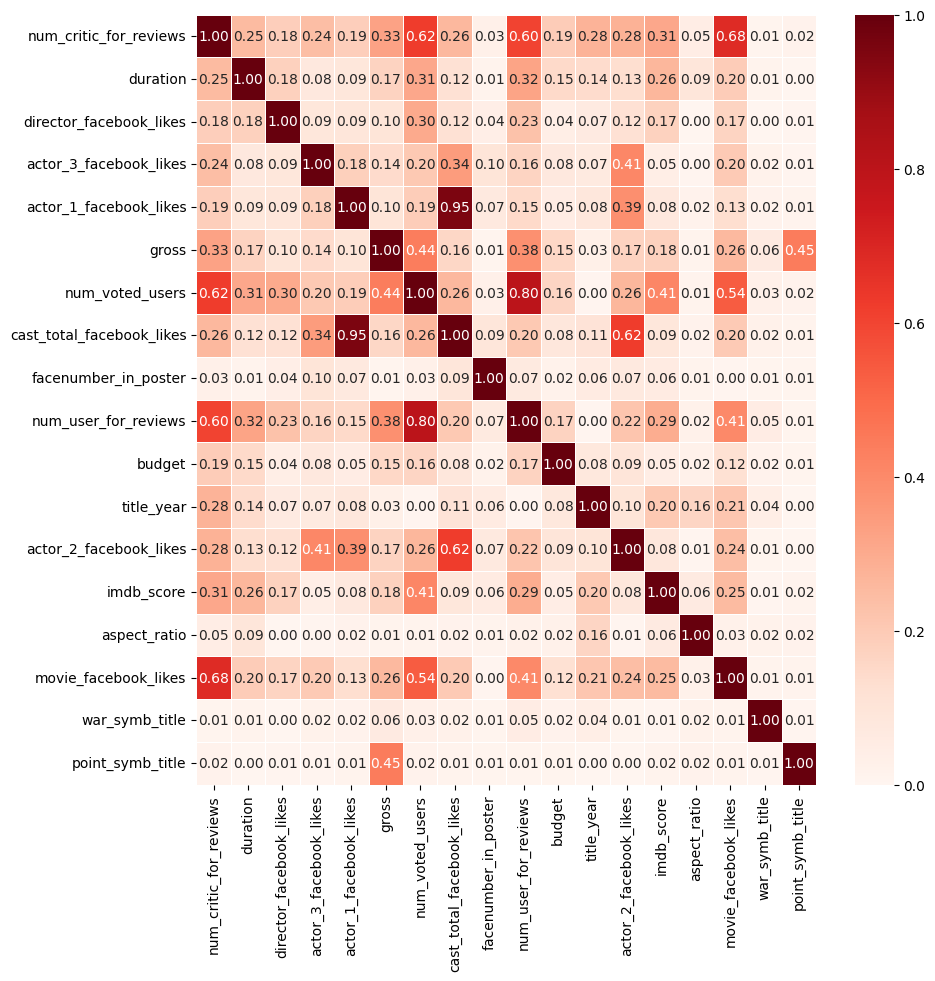

In [26]:
plt.figure(figsize=(10,10))
sns.heatmap(abs(cor), cmap='Reds',annot=True, fmt=".2f",vmin=0, linewidths=0.7)

In [27]:
# cast_total_facebook_light obviously is highly correleted with actor_1/2/3_facebook_likes, so we should consider removing this feature
# point_symb_title and num_critic_for_review seem to be important in predicting budget

## 2.4 Relathionships between "gross" and "content_rating"

In [89]:
# Mututal information score
X = df[df.gross.notnull()].content_rating.astype('category').cat.codes.values.reshape(-1, 1)
y = df[df.gross.notnull()].gross

mi_score = mutual_info_regression(X, y)
print(f"Mutual Information Score: {mi_score}")

Mutual Information Score: [0.10554407]


In [93]:
df_not_nan_budget = df[df.gross.notnull()]
categories = df_not_nan_budget.content_rating.value_counts()
categories = categories[categories>0].index
df_f_test = df_not_nan_budget[df_not_nan_budget["content_rating"].isin(categories)]
date_per_cat = [df_f_test[df_f_test["content_rating"] == cat]['gross'] for cat in categories]
f_stat, p_val = stats.f_oneway(*date_per_cat)
print(f"F_test p_val = {round(p_val,5)}")

F_test p_val = 0.0


## 2.5 Feature engineering

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(,df.,test_size = 0.2, shuffle = True)

In [ ]:
df

array([[7],
       [7],
       [9],
       ...,
       [7],
       [7],
       [6]], shape=(3547, 1), dtype=int8)

In [86]:
a1 = set(x_train.actor_1_name)
a2 = set(df.actor_2_name)
a3 = set(df.actor_3_name)
len(a1 & a3), len(a1 & a2), len(a2 & a3), len(a1 & a2 & a3)

AttributeError: 'numpy.ndarray' object has no attribute 'actor_1_name'

In [82]:
all_actors = pd.concat([df['actor_1_name'], df['actor_2_name'], df['actor_3_name']]).value_counts()
all_actors

Robert De Niro     53
Morgan Freeman     43
Bruce Willis       38
Matt Damon         37
Steve Buscemi      36
                   ..
Conrad Kemp         1
Andrea Ros          1
Carlos Lasarte      1
Leila Arcieri       1
Paterson Joseph     1
Name: count, Length: 6252, dtype: int64

In [ ]:
df.actor_1_name.value_counts()
df.actor_2_name.value_counts()
df.actor_3_name.value_counts()

actor_1_name
Robert De Niro        48
Johnny Depp           36
Nicolas Cage          32
Denzel Washington     29
Matt Damon            29
                      ..
Kim Dickens            1
Jason K. Wixom         1
Jonathan D. Mellor     1
Manuela Velasco        1
Sunny Mabrey           1
Name: count, Length: 2096, dtype: int64

In [34]:
df.actor_3_name.value_counts()

actor_3_name
Steve Coogan       8
Ben Mendelsohn     7
Sam Shepard        7
Robert Duvall      7
Jon Gries          7
                  ..
Conrad Kemp        1
Andrea Ros         1
Carlos Lasarte     1
Leila Arcieri      1
Paterson Joseph    1
Name: count, Length: 3519, dtype: int64